In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
# Load Dataset
df = pd.read_csv("ODI data.csv")

# Display first 10 rows
df.head(10)

,Unnamed: 0,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Unnamed: 13
0,0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,NaN
1,1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,NaN
2,2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,NaN
3,3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.2,28,68,34,NaN
4,4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,NaN
5,5,Inzamam-ul-Haq (Asia/PAK),1991-2007,378,350,53,11739,137*,39.52,15812,74.24,10,83,20,NaN
6,6,V Kohli (INDIA),2008-2019,242,233,39,11609,183,59.84,12445,93.28,43,55,13,NaN
7,7,JH Kallis (Afr/ICC/SA),1996-2014,328,314,53,11579,139,44.36,15885,72.89,17,86,17,NaN
8,8,SC Ganguly (Asia/INDIA),1992-2007,311,300,23,11363,183,41.02,15416,73.7,22,72,16,NaN
9,9,R Dravid (Asia/ICC/INDIA),1996-2011,344,318,40,10889,153,39.16,15284,71.24,12,83,13,NaN


The dataset contains historical performance statistics of ODI cricket players.
It includes both numerical and categorical variables.
The Runs column is a continuous numeric variable suitable for regression.
Cricket statistics are easy to interpret and analyze.
Relationships between matches played, innings, batting average, strike rate, and runs can be studied.
The dataset is appropriate for data preprocessing and exploratory data analysis.

In [4]:
# Missing values count
missing = df.isnull().sum()

# Missing percentage
missing_percent = (df.isnull().sum()/len(df))*100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

print(missing_df)
df = df.drop(columns=['Unnamed:13'], errors='ignore')

print("Duplicate Rows :", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

             Missing Values  Percentage
Unnamed: 0                0         0.0
Player                    0         0.0
Span                      0         0.0
Mat                       0         0.0
Inns                      0         0.0
NO                        0         0.0
Runs                      0         0.0
HS                        0         0.0
Ave                       0         0.0
BF                        0         0.0
SR                        0         0.0
100                       0         0.0
50                        0         0.0
0                         0         0.0
Unnamed: 13            2500       100.0
Duplicate Rows : 0
Shape after removing duplicates: (2500, 15)


One useless column contained only missing values.
Removing it does not affect analysis.
Remaining dataset is complete.
No duplicate records were present.

In [6]:
# Convert numeric columns if needed
numeric_cols = ['Mat','Inns','NO','Runs','HS','Ave','BF','SR','100','50','0']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Statistical summary
print(df.describe())
print("Minimum Runs :", df['Runs'].min())

print("Maximum Runs :", df['Runs'].max())

print("Mean Runs :", df['Runs'].mean())

print("Median Runs :", df['Runs'].median())

        Unnamed: 0          Mat         Inns           NO          Runs  \
count  2500.000000  2500.000000  2490.000000  2490.000000   2490.000000   
mean     24.500000    37.161600    29.605622     5.496787    676.234538   
std      14.433757    58.885075    51.380511     9.362150   1616.848599   
min       0.000000     1.000000     1.000000     0.000000      0.000000   
25%      12.000000     4.000000     3.000000     0.000000     22.000000   
50%      24.500000    13.000000    10.000000     2.000000    100.500000   
75%      37.000000    43.000000    31.000000     6.000000    479.500000   
max      49.000000   463.000000   452.000000    84.000000  18426.000000   

                HS          Ave            BF           SR          100  \
count  1705.000000  2370.000000   2490.000000  2481.000000  2490.000000   
mean     47.690909    18.280996    905.231325    63.577731     0.725703   
std      42.301706    12.808239   2062.373445    26.810820     2.937931   
min       0.000000     0

1.The Runs variable is highly positively skewed.
2.Most players have scored relatively few runs.
3.A small number of legendary players have extremely high totals.
4.Large difference between mean and maximum indicates presence of outliers.

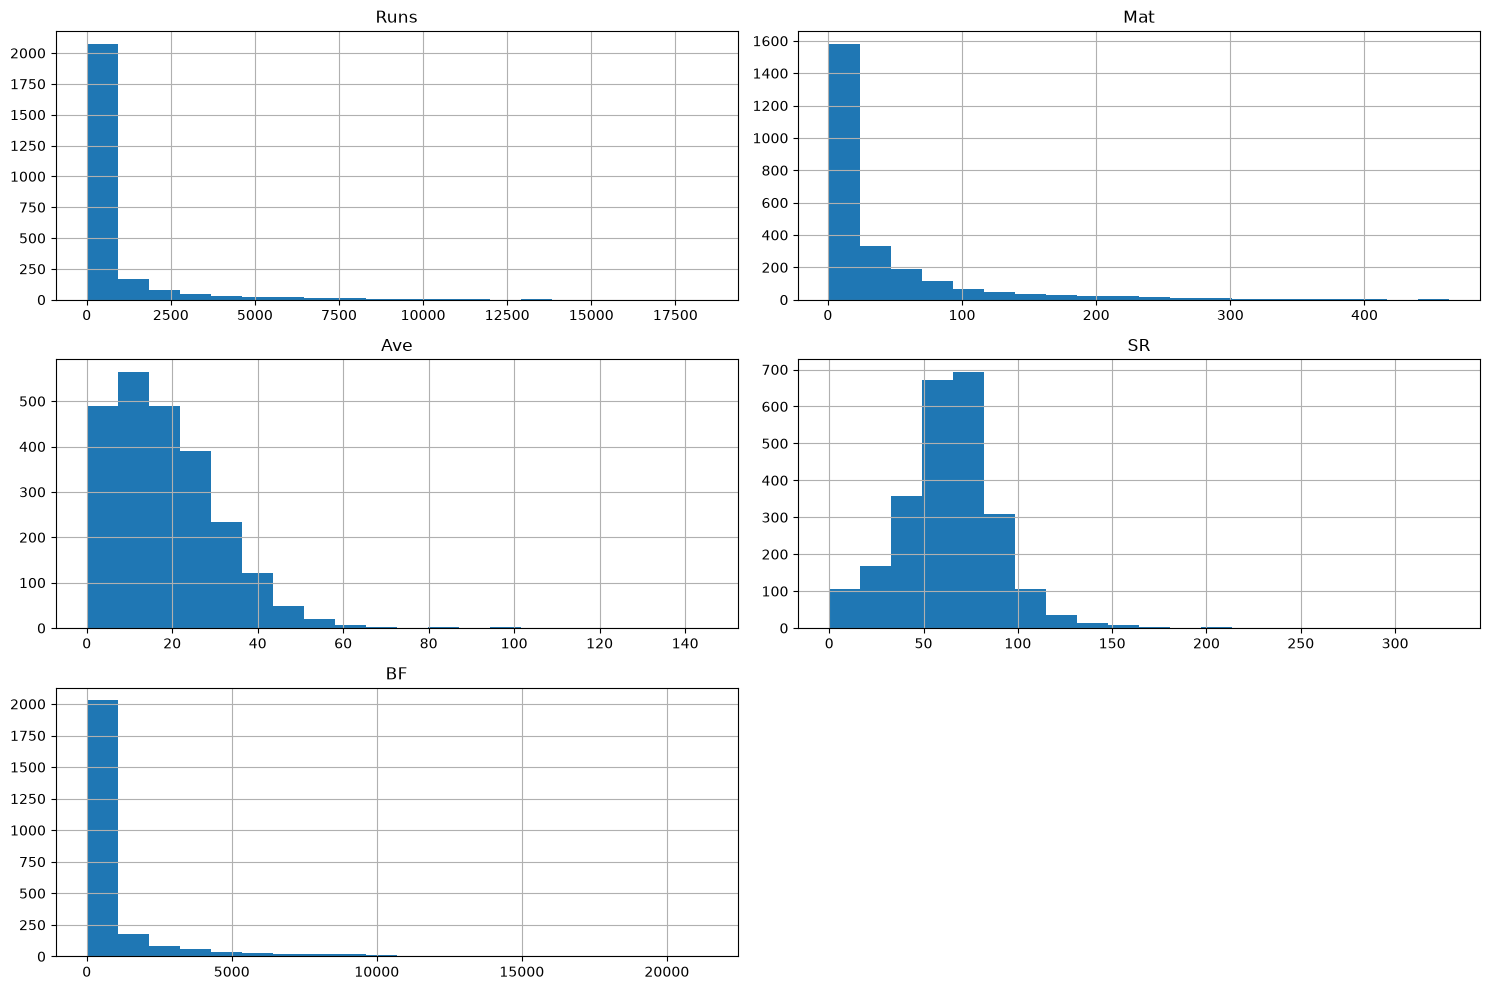

In [9]:
numeric_columns = ['Runs','Mat','Ave','SR','BF']

df[numeric_columns].hist(figsize=(15,10), bins=20)

plt.tight_layout()

plt.show()

Runs:-
Highly right-skewed.
Most players scored under 1000 runs.
Very few players crossed 10,000 runs.

Matches:-
Majority played fewer than 50 matches.
Very few players played more than 300 matches.

Batting Average:-
Most averages lie between 20–40.
Only a handful have averages above 50.

Strike Rate:-
Most strike rates range between 60–100.
Very high strike rates are uncommon.

Balls Faced:-
Distribution follows Runs closely.
Players facing more balls generally score more runs.

Index(['Player', 'Span'], dtype='str')


C:\Users\chede appliances\AppData\Local\Temp\ipykernel_22456\3219674420.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


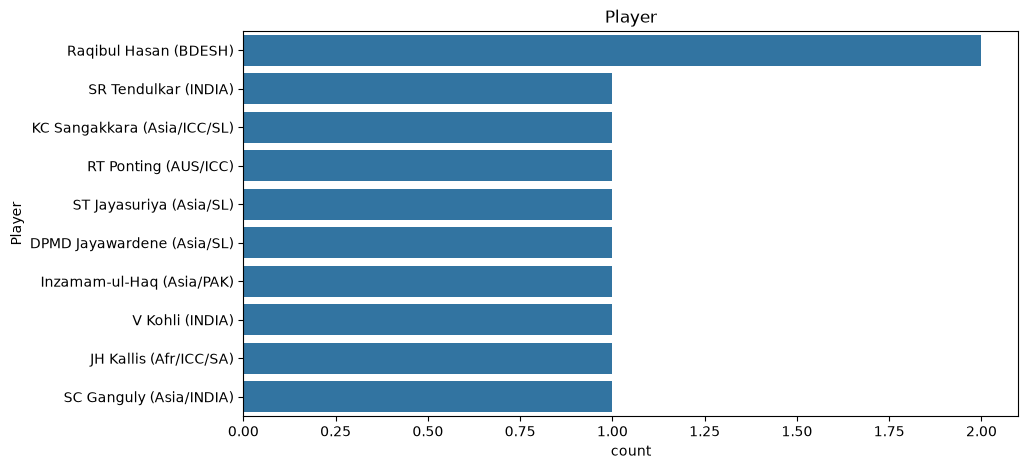

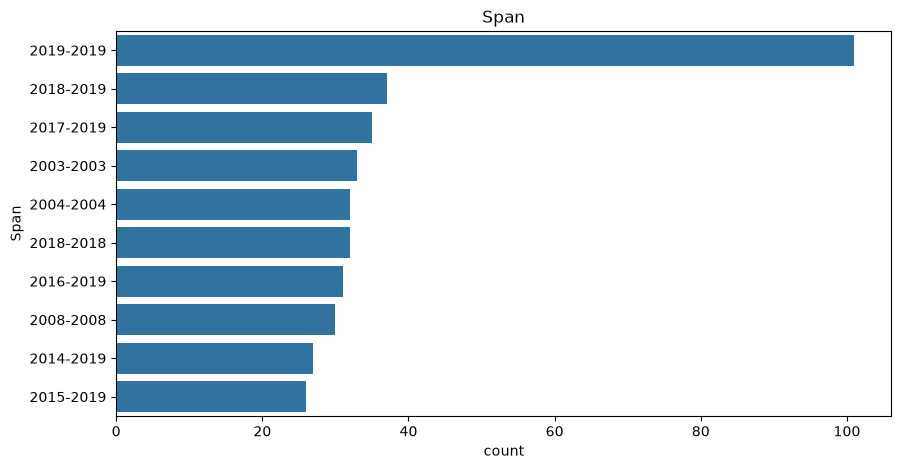

In [10]:
categorical_columns = df.select_dtypes(include='object').columns

print(categorical_columns)
for col in categorical_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])
    plt.title(col)
    plt.show()

Categorical Columns:-
Player
Span

Business/Domain Insights:-

Player

Every player appears only once.
Count plot simply confirms unique player records.

Span

Most careers fall between the late 1990s and early 2010s.
Few players have exceptionally long careers.
Different eras can be compared using this feature.

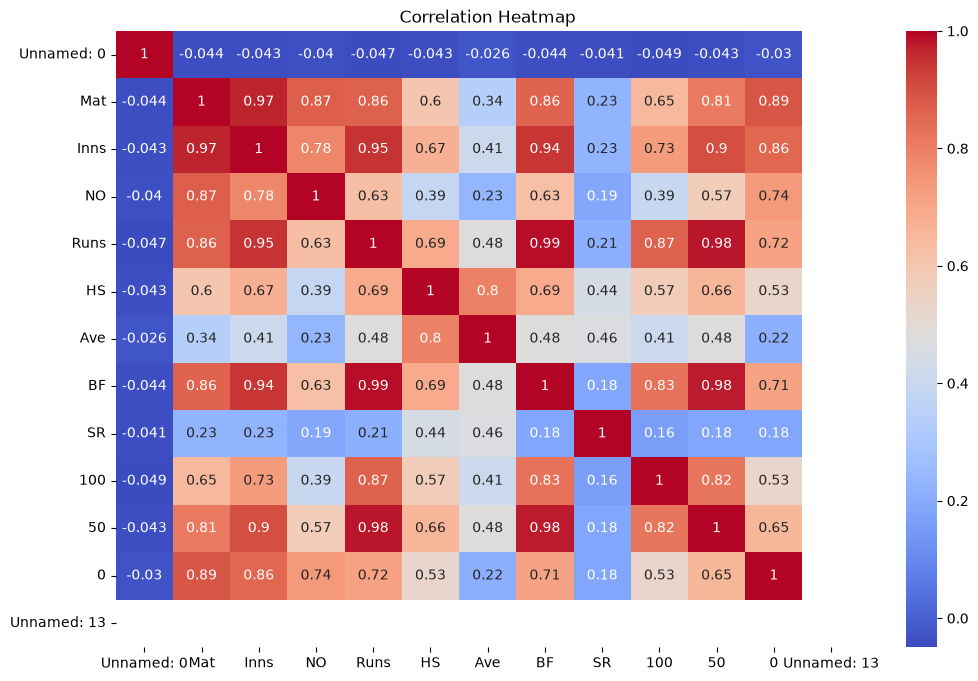

Runs           1.000000
BF             0.989950
50             0.979736
Inns           0.946907
100            0.867527
Mat            0.864878
0              0.716609
HS             0.691316
NO             0.628974
Ave            0.481927
SR             0.210437
Unnamed: 0    -0.047080
Unnamed: 13         NaN
Name: Runs, dtype: float64


In [12]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()
corr = numeric_df.corr()['Runs'].sort_values(ascending=False)

print(corr)

Strong Positive Correlations with Runs:-
Matches
Innings
Balls Faced
Number of 100s
Number of 50s

Moderate Correlation:-
Batting Average
Weak Correlation:-
Number of Ducks (0)

Observations:-
More matches generally lead to more runs.
Balls faced has one of the strongest correlations with runs.
Centuries and half-centuries strongly indicate higher run totals.
Ducks have little predictive value.

In [ ]:
# Target Variable
y = df['Runs']

# Independent Variables
X = df.drop(columns=['Runs'])

print("Independent Features")
print(X.columns)

print("\nDependent Feature")
print(y.name)

Independent Variables (X)
Mat
Inns
NO
HS
Ave
BF
SR
100
50
0

(Encoded categorical variables can also be included if required.)

Dependent Variable (y)

Runs

Justification

Runs is the quantity we want to predict. All other batting statistics influence the total runs scored, making them appropriate independent variables.

In [ ]:
print(df[['Player','Span']].head())
df_encoded = pd.get_dummies(df,
                            columns=['Player','Span'],
                            drop_first=True)

print(df_encoded.head())
print("Original Shape :", df.shape)

print("Encoded Shape :", df_encoded.shape)

Why One-Hot Encoding?
Suitable for nominal categorical variables.
Prevents introducing false ordinal relationships.
Makes the data compatible with machine learning algorithms.

In [15]:
# Define X and y after encoding
X = df_encoded.drop(columns=['Runs'])

y = df_encoded['Runs']
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
scaled_df = pd.DataFrame(X_scaled,
                         columns=X.columns)

scaled_df.head()
print(scaled_df.head())

c:\Users\chede appliances\Documents\ITR\.venv\Lib\site-packages\sklearn\utils\extmath.py:1211: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\chede appliances\Documents\ITR\.venv\Lib\site-packages\sklearn\utils\extmath.py:1216: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\chede appliances\Documents\ITR\.venv\Lib\site-packages\sklearn\utils\extmath.py:1240: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


   Unnamed: 0       Mat      Inns        NO        HS       Ave        BF  \
0   -1.697749  7.233133  8.222558  3.792969       NaN  2.073244  9.923459   
1   -1.628453  6.230981  6.820967  3.792969  2.868553  1.850684  8.313825   
2   -1.559158  5.738398  6.528969  3.579300  2.750320  1.854589  7.827879   
3   -1.489862  6.927392  7.852694  1.335775  3.341486  1.099447  6.702251   
4   -1.420566  6.978349  7.560695  3.579300  2.277387  1.178319  7.330294   

         SR        100        50  ...  Span_2016-2016  Span_2016-2017  \
0  0.845063  16.434691  9.364363  ...        -0.08516       -0.044766   
1  0.570119   8.264037  9.060423  ...        -0.08516       -0.044766   
2  0.627197   9.966257  7.945977  ...        -0.08516       -0.044766   
3  1.030473   9.285369  6.527590  ...        -0.08516       -0.044766   
4  0.573849   6.221373  7.439410  ...        -0.08516       -0.044766   

   Span_2016-2018  Span_2016-2019  Span_2017-2017  Span_2017-2018  \
0       -0.069449       -0.11